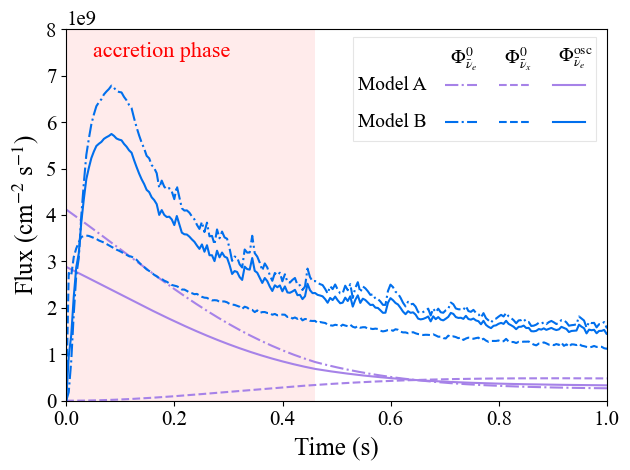

In [4]:
from Simulation_Spectrum import time_limit
from Simulation_Spectrum import flux_emulator_e, flux_emulator_x
import numpy as np
import matplotlib.pyplot as plt
import definition as df
from SignalRate_1d_osc import Flux_total_e, Flux_total_x, Flux_total


ranges_K: list = [(0, 30), (7, 50),  (-1, 1)]

fix_0 = [11.33, 4.21, 4.49, 0.12, 2.01, 0.46, -4, -12]

t_space = np.linspace(0, 10, 1000)       # unit s
E_space = np.linspace(7, 50, 300)


fig, ax = plt.subplots()

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

label_fontsize = 18
tick_fontsize = 15

y_e_1 = df.gl_integrate(lambda x: Flux_total_e(t_space, x, *fix_0), 7, 50)
y_x_1 = df.gl_integrate(lambda x: Flux_total_x(t_space, x, *fix_0), 7, 50)
y_total_1 = df.gl_integrate(lambda x: Flux_total(t_space, x, *fix_0), 7, 50)

ax.plot(t_space, y_e_1, color = "#A682E8", linestyle ='-.')
ax.plot(t_space, y_x_1, color = "#A682E8",linestyle ='--')
ax.plot(t_space, y_total_1, color = "#A682E8", linestyle = '-')

t_space_2 = np.linspace(0, time_limit('max'), 1000)

y_e_2 = df.gl_integrate(lambda x: flux_emulator_e(t_space_2, x), 7, 50)
y_x_2 = df.gl_integrate(lambda x: flux_emulator_x(t_space_2, x), 7, 50)
y_total_2 =  df.Ue1_2 * y_e_2 + (1-df.Ue1_2) * y_x_2

ax.plot(t_space_2, y_e_2, color = "#006FED", linestyle ='-.')
ax.plot(t_space_2, y_x_2, color = "#006FED",linestyle ='--')
ax.plot(t_space_2, y_total_2, color = "#006FED", linestyle = '-')

alpha_fill = 0.08
tau_a = fix_0[5]

ax.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = 'red', alpha = alpha_fill,  edgecolor = 'none')

# ax.vlines(0.65, ymin=0, ymax=3e10, color='red', linestyle='--', label = r'$\tau_a$')
ax.set_xlabel('Time (s)', fontsize=label_fontsize)
ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
ax.set_ylim(0, 0.8e10)
ax.set_xlim(0, 1.)


# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-.', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='--', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.70+x_shift, 0.76+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-', transform=ax.transAxes)


# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-.', transform=ax.transAxes)
ax.text(0.51+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=14, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row2, y_row2], color="#006FED", linestyle='--', transform=ax.transAxes)
ax.text(0.61+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=14, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.7+x_shift, 0.76+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-', transform=ax.transAxes)
ax.text(0.71+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=14, va='center', transform=ax.transAxes)

ax.text(0.34+x_shift, y_row1, 'Model A', fontsize=14, va='center', transform=ax.transAxes)
ax.text(0.34+x_shift, y_row2, 'Model B', fontsize=14, va='center', transform=ax.transAxes)
ax.text(0.05, 7.5e9, 'accretion phase', fontsize=16, va='center', color='red')

from matplotlib import patches
ax.add_patch(patches.Rectangle((0.33+x_shift, 0.65+y_shift), 0.45, 0.28, fill=False, edgecolor=(0.5, 0.5, 0.5, 0.2), 
    linewidth=0.8, transform=ax.transAxes))

plt.tight_layout()

# plt.savefig(r'F:/Neutrino_SI/Plots/flux_osc.pdf')

fig

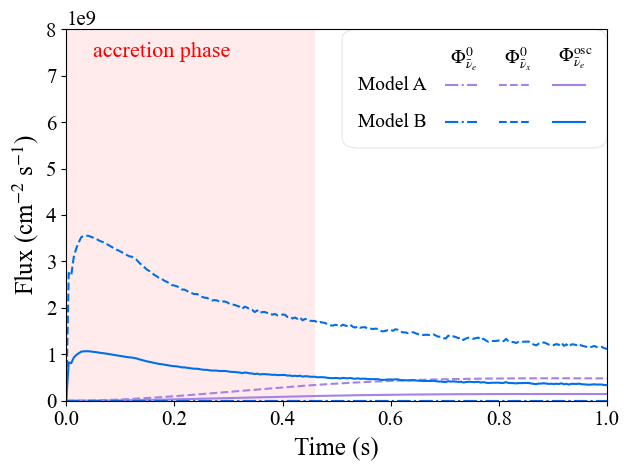

In [5]:
from Simulation_Spectrum import time_limit
from Simulation_Spectrum import flux_emulator_e, flux_emulator_x
import numpy as np
import matplotlib.pyplot as plt
import definition as df
from SignalRate_1d_osc import Flux_total_e, Flux_total_x, Flux_total
from SignalRate_2d_osc import flux_2d, flux_2d_e, flux_2d_x

ranges_K: list = [(0, 30), (7, 50),  (-1, 1)]

fix_0 = [11.33, 4.21, 4.49, 0.12, 2.01, 0.46, 2, -4]

t_space = np.linspace(0, 10, 1000)       # unit s
E_space = np.linspace(7, 50, 300)


fig, ax = plt.subplots()

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

label_fontsize = 18
tick_fontsize = 15

y_e_1_r = df.gl_integrate(lambda x: Flux_total_e(t_space, x, *fix_0), 7, 50)
y_x_1_r = df.gl_integrate(lambda x: Flux_total_x(t_space, x, *fix_0), 7, 50)
y_total_1_r = df.gl_integrate(lambda x: Flux_total(t_space, x, *fix_0), 7, 50)

ax.plot(t_space, y_e_1_r, color = "#A682E8", linestyle ='-.')
ax.plot(t_space, y_x_1_r, color = "#A682E8",linestyle ='--')
ax.plot(t_space, y_total_1_r, color = "#A682E8", linestyle = '-')

t_space_2 = np.linspace(0, time_limit('max'), 1000)

flux_2 = lambda x: flux_2d(t_space_2, x, *fix_0)

y_e_2_r = df.gl_integrate(lambda x: flux_2d_e(t_space_2, x, *fix_0), 7, 50)
y_x_2_r = df.gl_integrate(lambda x: flux_2d_x(t_space_2, x, *fix_0), 7, 50)
y_total_2_r =  df.gl_integrate(flux_2,  7, 50)

ax.plot(t_space_2, y_e_2_r, color = "#006FED", linestyle ='-.')
ax.plot(t_space_2, y_x_2_r, color = "#006FED",linestyle ='--')
ax.plot(t_space_2, y_total_2_r, color = "#006FED", linestyle = '-')


ax.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = 'red', alpha = alpha_fill, label = 'accretion phase', edgecolor = 'none')

# ax.vlines(0.65, ymin=0, ymax=3e10, color='red', linestyle='--', label = r'$\tau_a$')
ax.set_xlabel('Time (s)', fontsize=label_fontsize)
ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
ax.set_ylim(0, 0.8e10)
ax.set_xlim(0, 1.)



# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-.', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='--', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.70+x_shift, 0.76+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-', transform=ax.transAxes)


# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-.', transform=ax.transAxes)
ax.text(0.51+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=14, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row2, y_row2], color="#006FED", linestyle='--', transform=ax.transAxes)
ax.text(0.61+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=14, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.7+x_shift, 0.76+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-', transform=ax.transAxes)
ax.text(0.71+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=14, va='center', transform=ax.transAxes)

ax.text(0.34+x_shift, y_row1, 'Model A', fontsize=14, va='center', transform=ax.transAxes)
ax.text(0.34+x_shift, y_row2, 'Model B', fontsize=14, va='center', transform=ax.transAxes)
ax.text(0.05, 7.5e9, 'accretion phase', fontsize=16, va='center', color='red')

from matplotlib import patches
ax.add_patch(patches.FancyBboxPatch((0.33+x_shift, 0.65+y_shift), 0.45, 0.28, fill=False, edgecolor=(0.5, 0.5, 0.5, 0.2), boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=0.8, transform=ax.transAxes))


plt.tight_layout()

# plt.savefig(r'F:/Neutrino_SI/Plots/flux_osc_r.pdf')

fig

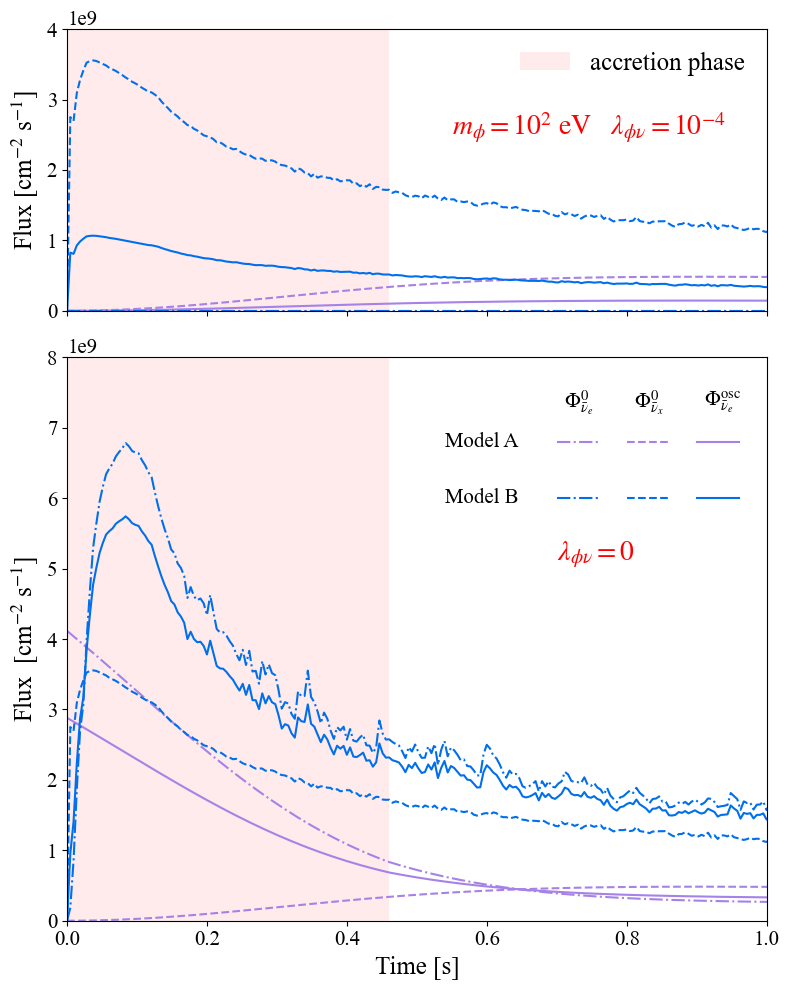

In [11]:
# Creat a figure combining two figures with a shared x-axis

fig, (axr, ax) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 10),gridspec_kw={'height_ratios': [1, 2]})

# ax bottom and axr top
ax.plot(t_space, y_e_1, color = "#A682E8", linestyle ='-.')
ax.plot(t_space, y_x_1, color = "#A682E8",linestyle ='--')
ax.plot(t_space, y_total_1, color = "#A682E8", linestyle = '-')
ax.plot(t_space_2, y_e_2, color = "#006FED", linestyle ='-.')
ax.plot(t_space_2, y_x_2, color = "#006FED",linestyle ='--')
ax.plot(t_space_2, y_total_2, color = "#006FED", linestyle = '-') 
ax.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = 'red', alpha = alpha_fill,edgecolor = 'none')

axr.plot(t_space, y_e_1_r, color = "#A682E8", linestyle ='-.')
axr.plot(t_space, y_x_1_r, color = "#A682E8",linestyle ='--')
axr.plot(t_space, y_total_1_r, color = "#A682E8", linestyle = '-')
axr.plot(t_space_2, y_e_2_r, color = "#006FED", linestyle ='-.')
axr.plot(t_space_2, y_x_2_r, color = "#006FED",linestyle ='--')
axr.plot(t_space_2, y_total_2_r, color = "#006FED", linestyle = '-')
axr.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = 'red', alpha = alpha_fill, label = 'accretion phase', edgecolor = 'none')


ax.set_xlabel('Time [s]', fontsize=label_fontsize)
ax.set_ylabel(r'Flux  [cm$^{-2}$ s$^{-1}$]', fontsize=label_fontsize)
ax.set_xlim(0, 1.)
ax.set_ylim(0, 0.8e10)

axr.set_ylim(0, 0.4e10)
axr.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$]', fontsize=label_fontsize)
axr.set_yticks([0, 0.1e10, 0.2e10, 0.3e10, 0.4e10])
plt.subplots_adjust(hspace=0.1)

axr.legend(fontsize=label_fontsize, loc='upper right', frameon=False)

ax.tick_params(labelsize=tick_fontsize)
axr.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
axr.yaxis.get_offset_text().set_fontsize(tick_fontsize)


# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-.', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='--', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.70+x_shift, 0.76+x_shift], [y_row1, y_row1], color="#A682E8", linestyle='-', transform=ax.transAxes)

# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-.', transform=ax.transAxes)
ax.text(0.51+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row2, y_row2], color="#006FED", linestyle='--', transform=ax.transAxes)
ax.text(0.61+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.7+x_shift, 0.76+x_shift], [y_row2, y_row2], color="#006FED", linestyle='-', transform=ax.transAxes)
ax.text(0.71+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

ax.text(0.34+x_shift, y_row1, 'Model A', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.34+x_shift, y_row2, 'Model B', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.5+x_shift, y_row2-0.1, r'$\lambda_{\phi\nu} = 0$', fontsize=20, va='center', transform=ax.transAxes, color = 'red')
axr.text(0.35+x_shift, y_row2-0.1, r'$m_\phi = 10^2 ~ {\rm eV} \quad \lambda_{\phi\nu} = 10^{-4}$', fontsize=20, va='center', transform=axr.transAxes, color = 'red')

# from matplotlib import patches
# ax.add_patch(patches.FancyBboxPatch((0.33+x_shift, 0.65+y_shift), 0.43, 0.25, fill=False, edgecolor=(0.5, 0.5, 0.5, 0.2), boxstyle="round,pad=0.02,rounding_size=0.03",
#     linewidth=0.8, transform=ax.transAxes))

plt.tight_layout()
fig.savefig(r'F:/Neutrino_SI/Plots/flux_osc_combined.pdf')

fig
